# Kmean Clustering

## 1. Import and Generate Dataset

In [108]:
import random
import math
import matplotlib.pyplot as plt

In [109]:
import random

random.seed(42)

data = []

# Cluster 1 arounds (2,2)
for _ in range(60):
    data.append((
        random.uniform(0.5, 3.5),
        random.uniform(0.5, 3.5)
    ))

# Cluster 2 arounds (8,8)
for _ in range(60):
    data.append((
        random.uniform(6.5, 9.5),
        random.uniform(6.5, 9.5)
    ))

# Cluster 3 arounds (2,8)
for _ in range(60):
    data.append((
        random.uniform(0.5, 3.5),
        random.uniform(6.5, 9.5)
    ))

# Cluster 4 around (8,2)
for _ in range(60):
    data.append((
        random.uniform(6.5, 9.5),
        random.uniform(0.5, 3.5)
    ))

# Outliers
outliers = [
    (0, 10),
    (10, 0),
    (10, 10),
    (5, 12),
    (12, 5),

    (4.5, 10.5),
    (5.5, 10.2),

    (10.5, 4.5),
    (10.2, 5.5),

    (5.0, 5.0),
    (4.8, 5.2),
    (5.2, 4.8),
]

data.extend(outliers)

random.shuffle(data)

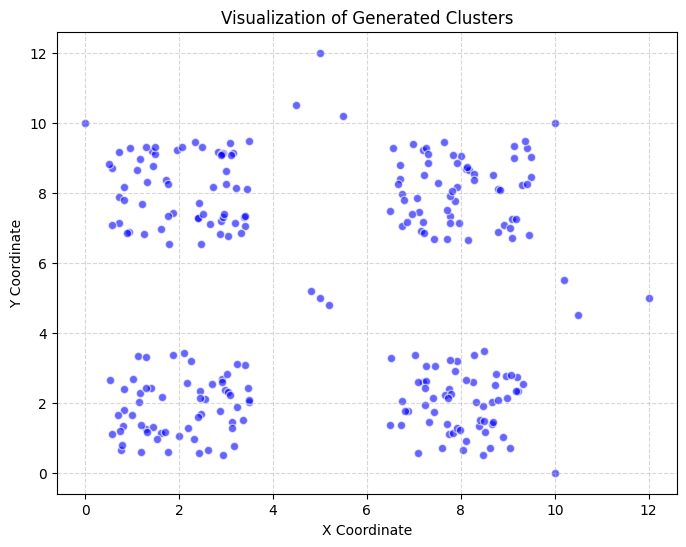

In [110]:
# Extract x and y coordinates from the data list
x_coords = [p[0] for p in data]
y_coords = [p[1] for p in data]

# Create a scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(x_coords, y_coords, color='blue', alpha=0.6, edgecolors='w')
plt.title('Visualization of Generated Clusters')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 2. Kmean function

In [111]:
def distance(p1, p2):
  return math.sqrt(pow(p1[0] - p2[0], 2) + pow(p1[1] - p2[1], 2))

In [112]:
# Step 1: Assign cluster for each point with the current centroids
def assign_clusters(data, centroids):
  clusters = []

  for point in data:
    min_dist = float("inf")
    best_cluster = 0

    for i in range(len(centroids)):
      dist = distance(centroids[i], point)
      if dist < min_dist:
        best_cluster = i
        min_dist = dist

    clusters.append(best_cluster)

  return clusters

In [113]:
# Step 2: Update centroids base on the central of every point of the cluster
def update_centroids(data, clusters, k):
  cluster_count = [0] * k
  cluster_x_sum = [0] * k
  cluster_y_sum = [0] * k

  for i in range(len(data)):
    cluster_id = clusters[i]
    cluster_count[cluster_id] += 1
    cluster_x_sum[cluster_id] += data[i][0]
    cluster_y_sum[cluster_id] += data[i][1]

  new_centroids = []
  for i in range(k):
    new_centroids.append((cluster_x_sum[i] / cluster_count[i], cluster_y_sum[i] / cluster_count[i]))
  return new_centroids

In [114]:
# Step 3: Calculate Loss - Sum Squared Error
def calculate_sse(data, clusters, centroids):
  sse = 0
  for i, point in enumerate(data):
    cluster_id = clusters[i]
    centroid = centroids[cluster_id]

    sse += distance(point, centroid) ** 2

  return sse

## 3. Training

In [115]:
def kmeans(data, k, max_iters=20):
  # Get k points in data to be centroids
  centroids = random.sample(data, k)

  history = []

  for iteration in range(max_iters):
    clusters = assign_clusters(data, centroids)
    sse = calculate_sse(data, clusters, centroids)

    history.append({
        "iteration": iteration,
        "centroids": centroids[:],
        "clusters": clusters[:],
        "sse": sse
    })

    new_centroids = update_centroids(data, clusters, k)

    if new_centroids == centroids:
      break

    centroids = new_centroids

  return centroids, clusters, history

## 4. Plotting

In [116]:
def plot_kmeans_history(data, history):
  rows = 3
  cols = 3
  max_plots = rows * cols

  plt.figure(figsize=(16, 14))

  for plot_index in range(min(len(history), max_plots)):
    state = history[plot_index]

    centroids = state["centroids"]
    clusters  = state["clusters"]
    sse       = state["sse"]
    iteration = state["iteration"]

    plt.subplot(rows, cols, plot_index + 1)

    for cluster_id in range(len(centroids)):
      xs = []
      ys = []

      for i, point in enumerate(data):
        if clusters[i] == cluster_id:
          xs.append(point[0])
          ys.append(point[1])

      plt.scatter(xs, ys, s=25, label=f"C{cluster_id}")

    centroid_x = [c[0] for c in centroids]
    centroid_y = [c[1] for c in centroids]

    plt.scatter(
        centroid_x,
        centroid_y,
        marker="X",
        s=220,
        edgecolors="black",
        label="Centroids"
    )

    plt.title(f"Iter {iteration} | SSE = {sse:.2f}")
    plt.xlim(0, 10)
    plt.ylim(0, 10)
    plt.grid(True)
    plt.legend(fontsize=7)

  plt.tight_layout()
  plt.show()

In [117]:
def plot_centroid_paths(data, history):
    plt.figure(figsize=(8, 8))

    xs = [p[0] for p in data]
    ys = [p[1] for p in data]

    plt.scatter(xs, ys, s=20, alpha=0.4, label="Data")

    k = len(history[0]["centroids"])

    for cluster_id in range(k):
        path_x = []
        path_y = []

        for state in history:
            centroid = state["centroids"][cluster_id]
            path_x.append(centroid[0])
            path_y.append(centroid[1])

        plt.plot(path_x, path_y, marker="o", label=f"Centroid {cluster_id} path")

        plt.scatter(path_x[0], path_y[0], marker="s", s=120)
        plt.scatter(path_x[-1], path_y[-1], marker="X", s=200)

    plt.title("Centroid Movement During Training")
    plt.xlim(0, 10)
    plt.ylim(0, 10)
    plt.grid(True)
    plt.legend()
    plt.show()

In [118]:
def plot_sse(history):
    iterations = []
    losses = []

    for state in history:
        iterations.append(state["iteration"])
        losses.append(state["sse"])

    plt.figure(figsize=(8, 5))
    plt.plot(iterations, losses, marker="o")
    plt.title("SSE Loss During K-Means Training")
    plt.xlabel("Iteration")
    plt.ylabel("SSE")
    plt.grid(True)
    plt.show()

In [119]:
import matplotlib.pyplot as plt
from IPython.display import display

def plot_training_dashboard(data, history, k):
    colors = [
        "tab:blue", "tab:orange", "tab:green", "tab:red",
        "tab:purple", "tab:brown", "tab:pink", "tab:gray"
    ]

    num_steps = len(history)
    cols = 3
    rows = (num_steps + cols - 1) // cols

    fig = plt.figure(figsize=(18, rows * 5 + 6))

    # =========================
    # 1. Vẽ từng iteration
    # =========================
    for idx, state in enumerate(history):
        ax = fig.add_subplot(rows + 1, cols, idx + 1)

        clusters = state["clusters"]
        centroids = state["centroids"]

        for cluster_id in range(k):
            points = [
                data[i]
                for i, c in enumerate(clusters)
                if c == cluster_id
            ]

            if points:
                ax.scatter(
                    [p[0] for p in points],
                    [p[1] for p in points],
                    s=30,
                    alpha=0.6,
                    color=colors[cluster_id % len(colors)],
                    label=f"C{cluster_id}"
                )

        ax.scatter(
            [c[0] for c in centroids],
            [c[1] for c in centroids],
            marker="X",
            s=220,
            color="black",
            label="Centroids"
        )

        title = f"Iteration {state['iteration']}"
        if "sse" in state:
            title += f"\nSSE = {state['sse']:.2f}"

        ax.set_title(title)
        ax.set_xlim(0, 10)
        ax.set_ylim(0, 10)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    # =========================
    # 2. Centroid paths
    # =========================
    ax_path = fig.add_subplot(rows + 1, 2, rows * 2 + 1)

    ax_path.scatter(
        [p[0] for p in data],
        [p[1] for p in data],
        s=20,
        alpha=0.15,
        color="gray"
    )

    for cluster_id in range(k):
        path_x = [
            state["centroids"][cluster_id][0]
            for state in history
        ]
        path_y = [
            state["centroids"][cluster_id][1]
            for state in history
        ]

        ax_path.plot(
            path_x,
            path_y,
            marker="o",
            linewidth=2,
            color=colors[cluster_id % len(colors)],
            label=f"C{cluster_id}"
        )

        ax_path.scatter(path_x[0], path_y[0], marker="s", s=120)
        ax_path.scatter(path_x[-1], path_y[-1], marker="X", s=220, color="black")

    ax_path.set_title("Centroid Movement")
    ax_path.set_xlim(0, 10)
    ax_path.set_ylim(0, 10)
    ax_path.grid(True, alpha=0.3)
    ax_path.legend()

    # =========================
    # 3. SSE curve nếu có SSE
    # =========================
    ax_sse = fig.add_subplot(rows + 1, 2, rows * 2 + 2)

    if "sse" in history[0]:
        iterations = [s["iteration"] for s in history]
        sse_values = [s["sse"] for s in history]

        ax_sse.plot(iterations, sse_values, marker="o", linewidth=2)

        for x, y in zip(iterations, sse_values):
            ax_sse.text(x, y, f"{y:.1f}", fontsize=8)

        ax_sse.set_title("SSE During Training")
        ax_sse.set_xlabel("Iteration")
        ax_sse.set_ylabel("SSE")
        ax_sse.grid(True, alpha=0.3)
    else:
        ax_sse.text(
            0.5,
            0.5,
            "No SSE in history",
            ha="center",
            va="center",
            fontsize=16
        )
        ax_sse.axis("off")

    plt.tight_layout()

    # Quan trọng cho Colab
    display(fig)
    plt.close(fig)

/tmp/ipykernel_3560/3016090484.py:131: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


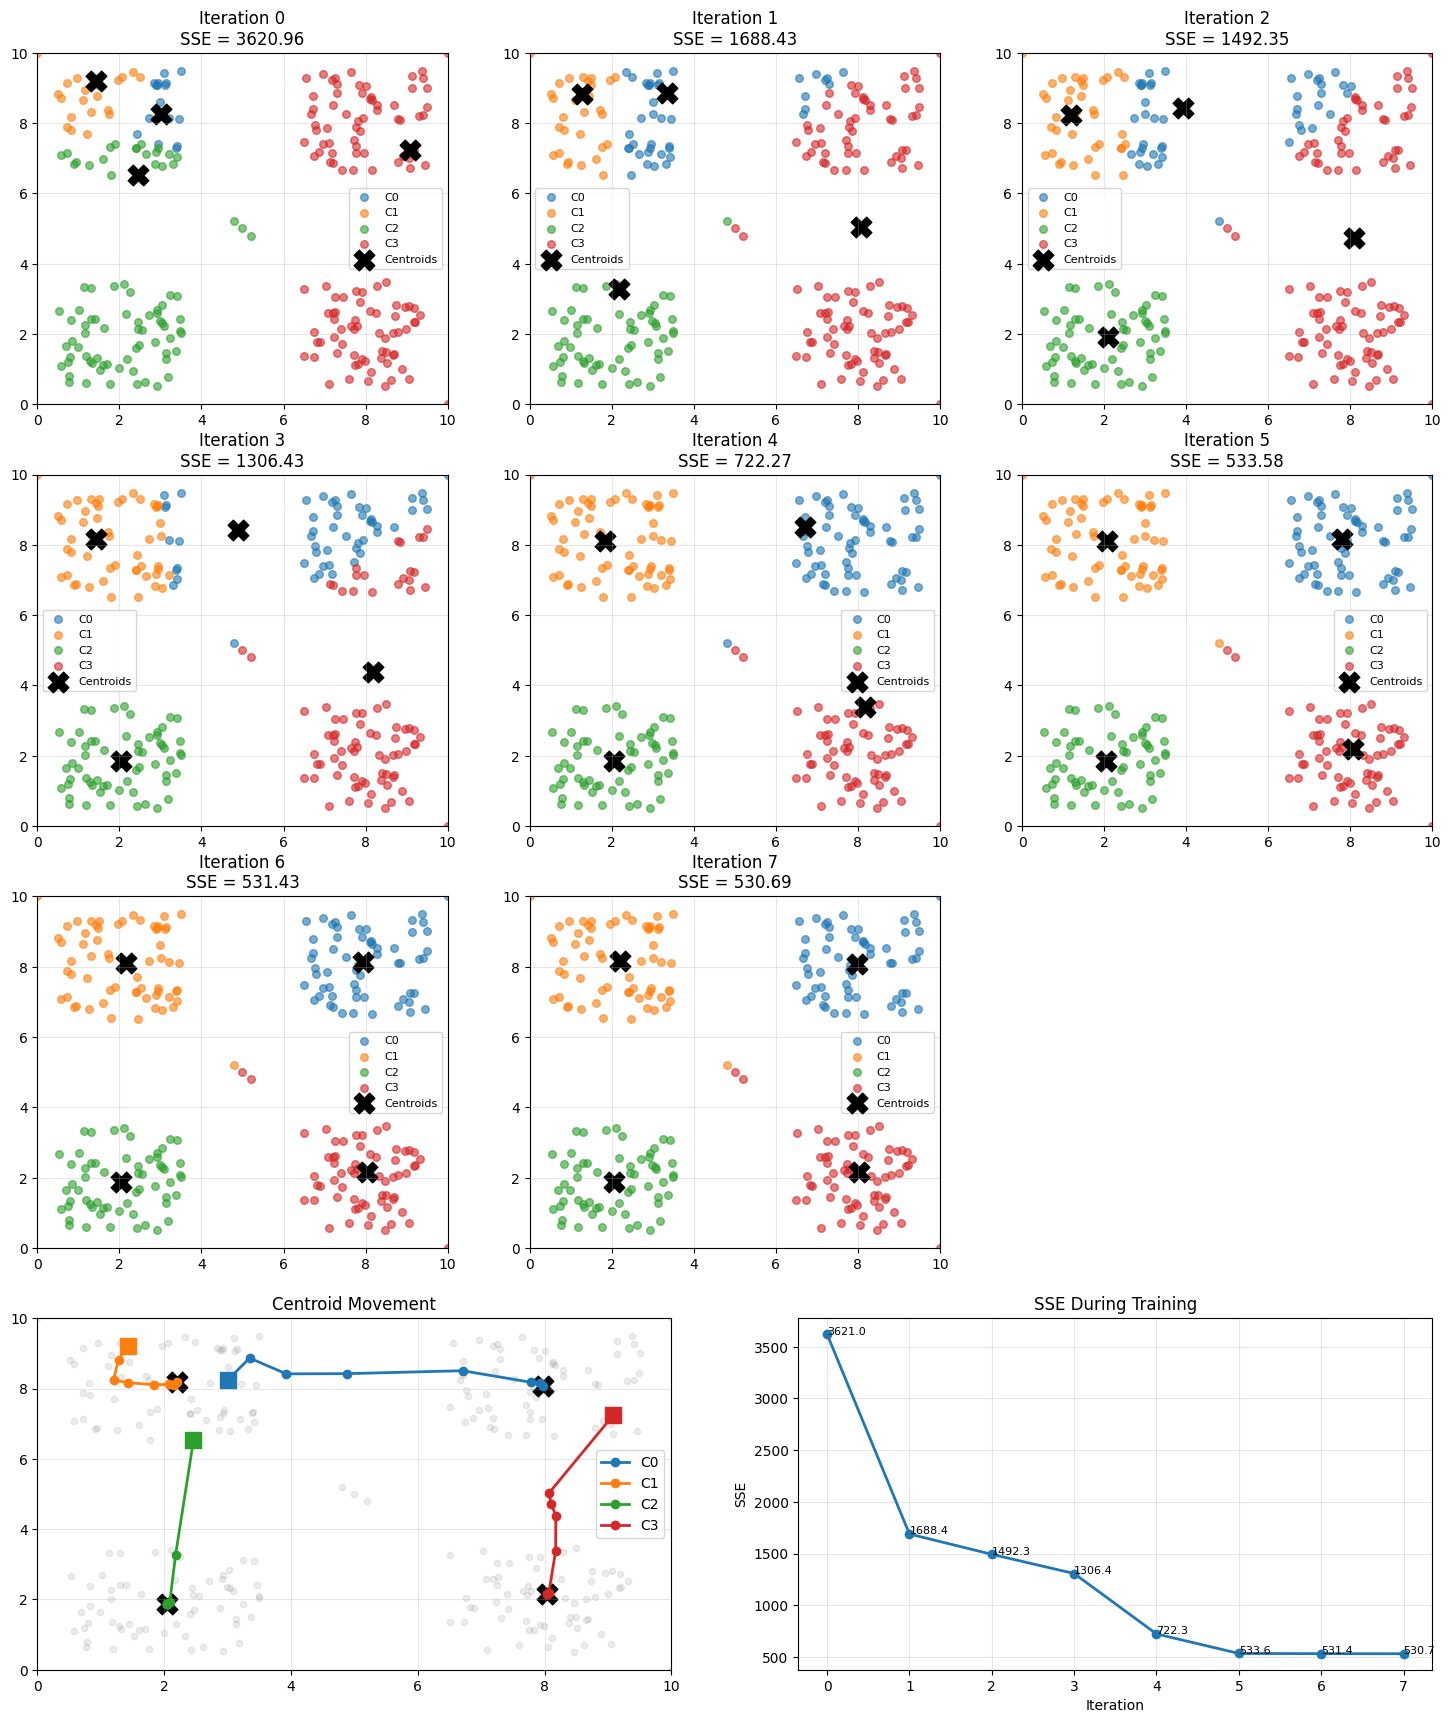

In [120]:
k = 4
centroids, clusters, history = kmeans(data, k, max_iters=10)

plot_training_dashboard(data, history, k)